In [ ]:
import pandas as pd
import matplotlib as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
df = pd.read_csv("/content/Customer_churn.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CustomerID      40 non-null     object 
 1   Age             40 non-null     int64  
 2   MonthlyCharges  40 non-null     float64
 3   Tenure          40 non-null     int64  
 4   SupportCalls    40 non-null     int64  
 5   Churn           40 non-null     object 
dtypes: float64(1), int64(3), object(2)
memory usage: 2.0+ KB


**FEATURES SELECTION**

In [ ]:

X = df.drop(["CustomerID", "Churn"], axis = 1)
y=df['Churn']

model = LogisticRegression()


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model.fit(X_train_scaled,y_train)

y_pred = model.predict(X_test_scaled)
print(y_test.values)
print(y_pred)



['No' 'No' 'Yes' 'Yes' 'Yes' 'No' 'Yes' 'No']
['Yes' 'No' 'Yes' 'Yes' 'Yes' 'No' 'Yes' 'No']


**EVALUATION METRICS**

In [ ]:
model_accuracy = accuracy_score(y_test , y_pred)
C_matrix = confusion_matrix(y_test , y_pred)

print("Customer_churn_accuracy:", model_accuracy)
print("Customer_churn_confusion_matrix:" ,C_matrix)

Customer_churn_accuracy: 0.875
Customer_churn_confusion_matrix: [[3 1]
 [0 4]]


**CROSS_VALIDATION_SCORE**

In [ ]:
score = cross_val_score (model,X_train_scaled, y_train, cv=5, scoring ="accuracy")
print("Cross_validation_score:",score)
print("Mean_accuracy:",score.mean())

Cross_validation_score: [1. 1. 1. 1. 1.]
Mean_accuracy: 1.0


In [ ]:
df.shape

(40, 6)

**MODEL RESULT INTERPRETATION**
The model achieved an accuracy of 87.5% on the separate test set, while the 5-fold cross-validation produced an accuracy of 100% across all folds. The difference may be related to the relatively small dataset and the limited number of observations in each fold. Therefore, the 100% cross-validation accuracy does not guarantee that the model will achieve 100% accuracy on unseen data. The test-set result of 87.5% provides an indication of how the model performs on unseen observations, but further evaluation on a larger dataset would provide a more reliable estimate of the model's performance.

MODEL VISUALISATION

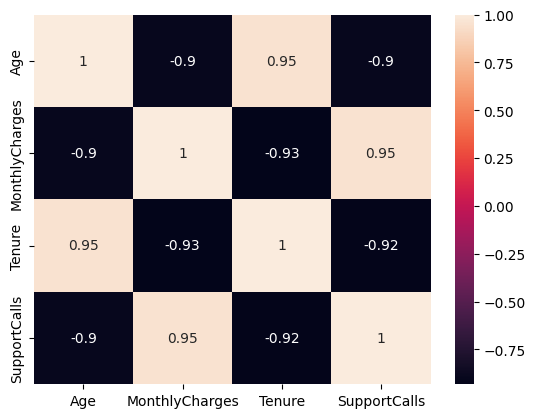

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()


"The correlation heatmap reveals strong positive and negative relationships among several numerical features. For example, Age and Tenure show a strong positive correlation, while MonthlyCharges and Tenure show a strong negative correlation. These results indicate association between the variables, but correlation does not imply causation.